# Dia 4 — LangGraph: controle de fluxo e human-in-the-loop

Nos dias anteriores usamos `create_agent` — uma caixa preta que decide tudo sozinha.  
Hoje assumimos o controle do fluxo com **LangGraph**.

Com LangGraph definimos o agente como um **grafo**: nós (ações) e arestas (transições).  
Isso permite:
- Decidir *explicitamente* o que acontece após cada passo
- Criar **bifurcações condicionais** baseadas no conteúdo
- **Pausar o grafo** e pedir confirmação humana antes de agir

| Parte | Tema |
|---|---|
| Setup | Conexões, credenciais, login no e-mail |
| A | Conceito de grafo — nós, arestas e estado |
| B | Grafo básico: loop ReAct com LangGraph |
| C | Nó condicional + Human-in-the-loop: detectar "cobrança" e pedir confirmação |

---

## Setup

In [ ]:
# Célula 1 — Instalar dependências
!pip install -q langchain-anthropic langchain langgraph

Configuração idêntica aos dias anteriores. Neste notebook usamos apenas a tool `send_email` — o foco aqui é o controle de fluxo, não a quantidade de ferramentas.

Configuramos o LLM e fazemos login no servidor de e-mail em uma única célula.

Definimos `send_email` — a mesma tool dos dias anteriores. Hoje ela é a única tool; isso nos permite focar inteiramente no grafo, sem distração com múltiplas ferramentas.

In [1]:
# Célula 2 — Credenciais
PROXY_URL      = "https://interview-server-mocado.b60gda.easypanel.host/"
ALUNO_TOKEN    = "xpto_aluno-01"

EMAIL_URL      = "https://interview-email-server.b60gda.easypanel.host/"
EMAIL_TOKEN    = "aluno-01"
EMAIL_PASSWORD = "1234"

print("Credenciais carregadas.")

Credenciais carregadas.


Configuramos o LLM e fazemos login no servidor de e-mail em uma única célula.

In [2]:
# Célula 3 — LLM e login no servidor de e-mail
import requests
from langchain_anthropic import ChatAnthropic
from langchain_core.messages import HumanMessage

llm = ChatAnthropic(
    model="claude-haiku-4-5-20251001",
    api_key=ALUNO_TOKEN,
    base_url=PROXY_URL,
    max_tokens=512,
)

resp = llm.invoke([HumanMessage(content="Responda apenas: conexão ok!")])
print("LLM:", resp.content)

login = requests.post(f"{EMAIL_URL}/auth/login", json={
    "token": EMAIL_TOKEN, "password": EMAIL_PASSWORD,
})
assert login.status_code == 200
_headers = {"Authorization": f"Bearer {EMAIL_TOKEN}"}
print("Email server: OK →", login.json())

C:\Users\mnsmferr\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


LLM: Conexão ok!
Email server: OK → {'token': 'aluno-01', 'name': 'Aluno 1', 'email': 'aluno01@curso.ia'}


Definimos `send_email` e `get_sent` — as duas tools deste notebook. Isso nos permite focar no grafo sem distração com muitas ferramentas.

In [13]:
# Célula 4 — Tools: send_email e get_sent
from langchain_core.tools import tool
from typing import Optional

@tool
def send_email(to: str, subject: str, body: str, cc: Optional[str] = None) -> str:
    """Envia um e-mail pelo servidor do curso.

    Args:
        to: E-mail do destinatário (ex: aluno02@curso.ia)
        subject: Assunto do e-mail
        body: Corpo completo do e-mail
        cc: E-mails em cópia, separados por vírgula (opcional)
    """
    payload = {"to": to, "subject": subject, "body": body}
    if cc:
        payload["cc"] = cc
    r = requests.post(f"{EMAIL_URL}/emails/send", headers=_headers, json=payload)
    if r.status_code in (200, 201):
        return f"E-mail enviado com sucesso para '{to}'."
    return f"Erro ao enviar ({r.status_code}): {r.json()}"

@tool
def get_sent() -> str:
    """Lista os e-mails enviados pelo usuário.

    Retorna id, data, destinatário e assunto de cada mensagem enviada.
    Use esta tool quando o usuário quiser ver os e-mails que já enviou.
    """
    r = requests.get(f"{EMAIL_URL}/emails/sent", headers=_headers)
    sent = r.json()
    if sent["count"] == 0:
        return "Nenhum e-mail enviado ainda."
    linhas = [f"Total: {sent['count']} mensagem(ns) enviada(s)\n"]
    for msg in sent["messages"]:
        destinatarios = ", ".join(msg["to"]) if isinstance(msg["to"], list) else msg["to"]
        linhas.append(
            f"ID: {msg['id']} | Data: {msg['timestamp']} | "
            f"Para: {destinatarios} | Assunto: {msg['subject']}"
        )
    return "\n".join(linhas)

print("Tools send_email e get_sent prontas.")

Tools send_email e get_sent prontas.


Montamos o grafo básico com três elementos: o **nó do LLM** (decide o que fazer), o **nó das tools** (executa as ações) e a **aresta condicional** (verifica se há tool call para decidir o próximo passo).

Testamos o grafo básico. O comportamento é idêntico ao `create_agent` do Dia 1 — mas agora temos acesso explícito a cada nó e podemos inspecionar e modificar o fluxo.

---
## Parte A — Como o LangGraph funciona

### `create_agent` vs LangGraph

| | `create_agent` | LangGraph |
|---|---|---|
| Fluxo | Automático (caixa preta) | Explícito (você define) |
| Bifurcações | Não suporta | Arestas condicionais |
| Pausas | Não suporta | `interrupt()` nativo |
| Debug | Difícil | Cada nó é inspecionável |

### Os três conceitos centrais

**Estado (`State`)** — um dicionário tipado que flui pelo grafo.  
Cada nó lê o estado, faz algo, e devolve o estado atualizado.

**Nós (`nodes`)** — funções Python que recebem o estado e retornam atualizações.  
Podem ser: o LLM, uma tool, uma função de decisão, um ponto de interrupção.

**Arestas (`edges`)** — conexões entre nós.  
Podem ser fixas (`A → B` sempre) ou condicionais (`A → B ou C` dependendo do estado).

---
## Parte B — Grafo básico com LangGraph

Vamos primeiro recriar o agente simples de envio de e-mail usando LangGraph,  
para entender a estrutura antes de adicionar complexidade.

Para construir o grafo vamos seguir três passos:

1. **Estado** — definir o `State`, o dicionário que flui pelo grafo
2. **Nós** — `no_agente` (chama o LLM) e `no_tools` (executa as tools)
3. **Arestas** — a aresta condicional `deve_usar_tool` decide se há tool call ou se o agente encerrou

**Estado** — usamos `add_messages` como reducer para que cada nova mensagem seja **acumulada** na lista, não substitua o estado inteiro.

**Nós e arestas** — montamos o grafo com `StateGraph`, adicionamos os dois nós e as arestas. A aresta condicional implementa o loop ReAct: se o LLM chamou uma tool, vai para `tools`; caso contrário, encerra.

**Visualização e teste** — visualizamos o diagrama do grafo e testamos com um prompt simples de envio de e-mail.

In [14]:
# Célula 5 — Definir o Estado do grafo
from typing import Annotated
from typing_extensions import TypedDict
from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages

class State(TypedDict):
    # add_messages é um reducer: acumula mensagens em vez de sobrescrever
    messages: Annotated[list[BaseMessage], add_messages]

print("Estado definido.")

Estado definido.


Montamos o grafo básico com três elementos: o **nó do LLM** (decide o que fazer), o **nó das tools** (executa as ações) e a **aresta condicional** (verifica se há tool call para decidir o próximo passo).

In [21]:
# Célula 6 — Construir o grafo básico
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode

tools = [send_email, get_sent]
llm_com_tools = llm.bind_tools(tools)

# Nó 1: o LLM decide o que fazer
def no_agente(state: State) -> dict:
    resposta = llm_com_tools.invoke(state["messages"])
    return {"messages": [resposta]}

# Aresta condicional: continua para tools ou termina?
def deve_usar_tool(state: State) -> str:
    ultima = state["messages"][-1]
    if hasattr(ultima, "tool_calls") and ultima.tool_calls:
        return "tools"
    return END

# Nó 2: executa as tools que o LLM escolheu
no_tools = ToolNode(tools)

# Montar o grafo
builder = StateGraph(State)
builder.add_node("agente", no_agente)
builder.add_node("tools", no_tools)

builder.add_edge(START, "agente")
builder.add_conditional_edges("agente", deve_usar_tool, {"tools": "tools", END: END})
builder.add_edge("tools", "agente")  # após executar tools, volta ao agente

grafo_basico = builder.compile()
print("Grafo básico compilado.")

Grafo básico compilado.


Visualizamos o grafo básico. O loop ReAct aparece claramente: `agente` ↔ `tools`, com saída condicional para `END`.

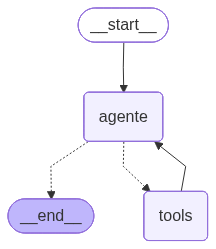

In [22]:
from IPython.display import Image
Image(grafo_basico.get_graph().draw_mermaid_png())

Testamos o grafo básico com um prompt de envio de e-mail:

O comportamento deve ser idêntico ao `create_agent` do Dia 1 — a diferença é que agora cada passo é explícito e inspecionável.

Com o grafo básico funcionando, adicionamos na Parte C a lógica condicional e o ponto de interrupção para confirmação humana.

In [23]:
# Célula 7 — Testar o grafo básico
from langchain_core.messages import HumanMessage

def invocar_grafo(grafo, prompt):
    resultado = grafo.invoke(
        {"messages": [HumanMessage(content=prompt)]}
    )
    return resultado["messages"][-1].content


In [24]:
# Teste 1: envia um e-mail
print("=== Teste 1: enviar e-mail ===")
print(invocar_grafo(
    grafo_basico,
    "Manda um e-mail para aluno02@curso.ia com assunto 'Olá' e corpo 'Testando o LangGraph!'"
))

=== Teste 1: enviar e-mail ===
Perfeito! O e-mail foi enviado com sucesso para aluno02@curso.ia com o assunto 'Olá' e o corpo 'Testando o LangGraph!' 📧


In [25]:

# Teste 2: consulta a caixa de saída
print("\n=== Teste 2: consultar enviados ===")
print(invocar_grafo(grafo_basico, "Quais e-mails eu já enviei?"))


=== Teste 2: consultar enviados ===
Você já enviou **29 e-mails** no total. Aqui está um resumo dos seus últimos envios:

**Mais recentes:**
1. **24/04/2026 03:23** - Para: aluno02@curso.ia | Assunto: Olá
2. **24/04/2026 03:21** - Para: aluno02@curso.ia | Assunto: Olá
3. **24/04/2026 02:34** - Para: aluno02@curso.ia | Assunto: Olá
4. **24/04/2026 02:15** - Para: aluno04@curso.ia | Assunto: Coleção feminina
5. **24/04/2026 02:15** - Para: aluno03@curso.ia | Assunto: Produtos de Eletrônicos em Destaque

**Principais destinatários:**
- **aluno02@curso.ia** - Múltiplos e-mails
- **aluno03@curso.ia** - Múltiplos e-mails (Reuniões, Middleware)
- **aluno05@curso.ia** - Confirmações e desmarcações de reuniões

**Assuntos mais comuns:**
- Reunião
- Confirmação/Desmarcação de Reunião
- Testes e convites

Gostaria de ver detalhes sobre algum e-mail específico ou enviar um novo?


---
## Parte C — Nó condicional + Human-in-the-loop

Agora adicionamos dois conceitos ao grafo:

1. **Aresta condicional** — `agente_para_onde` inspeciona o tool call diretamente e decide o destino em um único lugar
2. **`confirmacao_cobranca`** — nó que chama `interrupt()`, pausando o grafo até o humano responder

```
START → agente
             ↓ sem tool call
           END

             ↓ send_email com "cobrança"
   confirmacao_cobranca → interrupt()
             ↓ "sim" → tools → agente
             ↓ "não" → END

             ↓ get_sent ou send_email sem cobrança
           tools → agente
```

> **`interrupt()` vs middleware HITL do Dia 2:**  
> O middleware era **declarativo** — você listava quais tools precisavam de aprovação e o framework pausava automaticamente.  
> O `interrupt()` do LangGraph é **imperativo** — você coloca o ponto de pausa exatamente onde quiser no grafo, com acesso total ao estado.

In [ ]:
from langchain_core.messages import AIMessage

def agente_para_onde(state: State) -> str:
    """Após o agente: sem tool call → END. send_email com cobrança → confirmacao. Resto → tools."""
    ultima = state["messages"][-1]
    if not (hasattr(ultima, "tool_calls") and ultima.tool_calls):
        return END
    for tc in ultima.tool_calls:
        if tc["name"] == "send_email":
            assunto = tc["args"].get("subject", "").lower()
            if "cobrança" in assunto or "cobran" in assunto:
                return "confirmacao"
    return "tools"

print("Roteador definido.")

In [33]:
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt, Command
import uuid

def no_confirmacao_cobranca(state: State) -> dict:
    """Pausa o grafo e pede confirmação humana antes de enviar e-mail de cobrança."""
    ultima = state["messages"][-1]
    assunto = next(
        (tc["args"].get("subject", "") for tc in ultima.tool_calls if tc["name"] == "send_email"),
        ""
    )
    confirmacao = interrupt(
        f"⚠️  E-mail de cobrança detectado!\n"
        f"   Assunto: '{assunto}'\n"
        f"   Deseja realmente enviar este e-mail? (sim/não)"
    )
    if confirmacao.strip().lower() in ("sim", "s", "yes", "y"):
        return {}
    return {"messages": [AIMessage(content="Envio cancelado pelo usuário.")]}

def confirmacao_para_onde(state: State) -> str:
    ultima = state["messages"][-1]
    if isinstance(ultima, AIMessage) and "cancelado" in ultima.content:
        return END
    return "tools"

builder3 = StateGraph(State)
builder3.add_node("agente", no_agente)
builder3.add_node("tools", no_tools)
builder3.add_node("confirmacao_cobranca", no_confirmacao_cobranca)

builder3.add_edge(START, "agente")
builder3.add_conditional_edges(
    "agente", agente_para_onde,
    {"confirmacao": "confirmacao_cobranca", "tools": "tools", END: END},
)
builder3.add_conditional_edges(
    "confirmacao_cobranca", confirmacao_para_onde,
    {"tools": "tools", END: END},
)
builder3.add_edge("tools", "agente")

checkpointer = MemorySaver()
grafo_hitl = builder3.compile(checkpointer=checkpointer)
print("Grafo com HITL compilado.")

Grafo com HITL compilado.


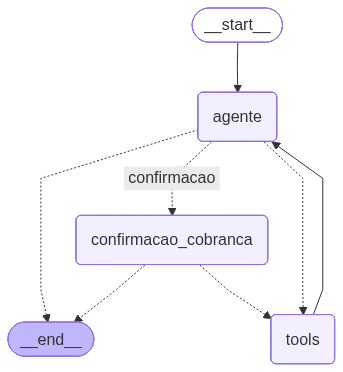

In [34]:
from IPython.display import Image
Image(grafo_hitl.get_graph().draw_mermaid_png())

In [ ]:
def invocar_hitl(grafo, prompt):
    """Invoca o grafo com suporte a interrupt — pede input do usuário se pausar."""
    config = {"configurable": {"thread_id": str(uuid.uuid4())}}
    resultado = grafo.invoke(
        {"messages": [HumanMessage(content=prompt)]},
        config=config,
    )
    interrupts = resultado.get("__interrupt__", [])
    if interrupts:
        print(interrupts[0].value)
        resposta_humano = input("\nSua resposta: ").strip()
        resultado = grafo.invoke(Command(resume=resposta_humano), config=config)
    return resultado["messages"][-1].content

print("invocar_hitl() pronta.")

In [ ]:
# Teste A — e-mail normal (sem interrupt)
print("=== E-mail NORMAL — sem interrupção ===")
print(invocar_hitl(
    grafo_hitl,
    "Manda um e-mail para aluno02@curso.ia com assunto 'Boas notícias' e corpo 'Tudo certo!'"
))

In [ ]:
# Teste B — e-mail de cobrança → responder "sim"
print("=== E-mail de COBRANÇA — responder 'sim' ===")
print(invocar_hitl(
    grafo_hitl,
    "Manda um e-mail para aluno03@curso.ia com assunto 'Cobrança de mensalidade' e corpo 'Sua mensalidade está em aberto.'"
))

In [ ]:
# Teste C — e-mail de cobrança → responder "não"
print("=== E-mail de COBRANÇA — responder 'não' ===")
print(invocar_hitl(
    grafo_hitl,
    "Manda um e-mail para aluno04@curso.ia com assunto 'Cobrança de mensalidade' e corpo 'Sua mensalidade está em aberto.'"
))

---
## Resumo do Dia 4

| Conceito | O que aprendemos |
|---|---|
| `StateGraph` | Grafo onde cada nó lê e atualiza um estado compartilhado |
| `add_conditional_edges` | Bifurca o fluxo dependendo do conteúdo do estado |
| `ToolNode` | Nó pronto do LangGraph que executa as tools chamadas pelo LLM |
| `interrupt()` | Pausa o grafo e devolve o controle ao humano |
| `MemorySaver` | Persiste o estado do grafo para permitir retomada após interrupt |
| `Command(resume=...)` | Retoma o grafo pausado com a resposta do humano |

### O que vem no Dia 5

- **Arquitetura de dois níveis**: orquestrador + sub-agente, cada um como `StateGraph` separado
- **Sub-agente de alertas**: recebe tipo e detalhes, escolhe a skill correta, busca os destinatários e envia os e-mails — tudo sozinho
- **Orquestrador**: decide entre delegar alertas complexos (`enviar_alerta`) ou agir diretamente (`send_email`)
- **Skills** (`.md`): arquivos de conhecimento externo que o sub-agente lê para saber como formatar cada tipo de alerta
